# **데이터 불러오기**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
import re
from scipy.stats import chi2_contingency, binomtest, fisher_exact, chisquare
from collections import Counter
from itertools import product

pd.set_option('display.max_columns', None)

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'

In [2]:
# ============================================================
# 한글 폰트 설치 및 적용
# ============================================================

!apt-get -qq install -y fonts-nanum > /dev/null
!pip -q install scipy pandas matplotlib

import matplotlib.font_manager as fm
for f in fm.findSystemFonts():
    if 'Nanum' in f:
        fm.fontManager.addfont(f)
print("폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.")


plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

폰트 설치 완료 → 런타임을 한 번 다시 시작하세요.


In [3]:
#파일 불러오기
df = pd.read_csv('아세트아미노펜_51개브랜드_전체행_최종.csv')
df.shape

(1248, 39)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   report_id             1248 non-null   int64 
 1   receive_date          1248 non-null   object
 2   quarter               1248 non-null   object
 3   serious               1248 non-null   object
 4   serious_flags         1248 non-null   object
 5   is_fatal              1248 non-null   bool  
 6   is_hospitalized       1248 non-null   bool  
 7   is_life_threat        1248 non-null   bool  
 8   is_disabling          1248 non-null   bool  
 9   reactions             1248 non-null   object
 10  primary_reaction      1248 non-null   object
 11  reaction_outcomes     1248 non-null   object
 12  patient_recovered     1248 non-null   bool  
 13  num_reactions         1248 non-null   int64 
 14  suspect_drug          1248 non-null   object
 15  brand_name            1248 non-null   

# **활성성분**

In [5]:
df['전체_활성성분'].value_counts(dropna=False)

,count
전체_활성성분,
AMAZON BASIC CARE ACETAMINOPHEN: Acetaminophen; PAIN RELIEF: Acetaminophen(제품별 상이 가능); MAXIMUM STRENGTH NON-ASPIRIN 100: Acetaminophen; MAXIMUM STRENGTH NON-ASPIRIN 250: Acetaminophen; INFANTS PAIN FEVER: Acetaminophen,748
TYLENOL COLD PLUS HEAD CONGESTION SEVERE: Acetaminophen + Phenylephrine; TYLENOL REGULAR STRENGTH: Acetaminophen; TYLENOL EXTRA STRENGTH: Acetaminophen,170
TYLENOL EXTRA STRENGTH: Acetaminophen; TYLENOL EXTRA STRENGTH CAPLET: Acetaminophen,154
TYLENOL REGULAR STRENGTH: Acetaminophen,36
TYLENOL 8 HR ARTHRITIS PAIN: Acetaminophen(서방형),28
CHILDRENS TYLENOL: Acetaminophen; CHILDRENS TYLENOL COLD PLUS FLU: Acetaminophen + Dextromethorphan + Chlorpheniramine; CHILDRENS TYLENOL COLD PLUS COUGH PLUS SORE THROAT: Acetaminophen + Dextromethorphan; CHILDRENS TYLENOL COLD PLUS COUGH PLUS RUNNY NOSE: Acetaminophen + Dextromethorphan + Chlorpheniramine,26
INFANTS TYLENOL: Acetaminophen,17
EXCEDRIN MIGRAINE: Acetaminophen + Aspirin + Caffeine,13
EXCEDRIN EXTRA STRENGTH GELTABS: Acetaminophen + Aspirin + Caffeine; EXCEDRIN EXTRA STRENGTH HEADACHE: Acetaminophen + Aspirin + Caffeine; EXCEDRIN MIGRAINE GELTABS: Acetaminophen + Aspirin + Caffeine; EXCEDRIN MIGRAINE: Acetaminophen + Aspirin + Caffeine; EXCEDRIN EXTRA STRENGTH PAIN RELIEVER: Acetaminophen + Aspirin + Caffeine,12


In [6]:
# ================================================================
# (아세트아미노펜) 데이터 전체 브랜드 개수 (매칭된_브랜드명 기준)
# ================================================================

all_brands = set()
for v in df['매칭된_브랜드명'].dropna():
    for b in str(v).split(';'):
        b = b.strip()
        if b:
            all_brands.add(b)

print(f'전체 브랜드 수: {len(all_brands)}개')

전체 브랜드 수: 51개


In [7]:
# ============================================================
# [사전 정의] 성분 조합 라벨(LABEL_KOR) + 파서(parse_combos)
# ============================================================

# 아세트아미노펜 외 동반 성분 후보
COMPANION_INGS = ['Phenylephrine', 'Chlorpheniramine', 'Dextromethorphan',
                  'Aspirin', 'Caffeine', 'Diphenhydramine', 'Doxylamine', 'Guaifenesin']

# 성분세트(frozenset) → (영문 라벨, 국문 라벨)
LABEL_KOR = {
    frozenset(): ('Acetaminophen (단일)', '아세트아미노펜 (단일)'),
    frozenset({'Phenylephrine'}):
        ('Acetaminophen + Phenylephrine', '아세트아미노펜 + 페닐에프린'),
    frozenset({'Chlorpheniramine', 'Dextromethorphan'}):
        ('Acetaminophen + Chlorpheniramine + Dextromethorphan', '아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판'),
    frozenset({'Aspirin', 'Caffeine'}):
        ('Acetaminophen + Aspirin + Caffeine', '아세트아미노펜 + 아스피린 + 카페인'),
    frozenset({'Dextromethorphan'}):
        ('Acetaminophen + Dextromethorphan', '아세트아미노펜 + 덱스트로메토르판'),
    frozenset({'Diphenhydramine'}):
        ('Acetaminophen + Diphenhydramine', '아세트아미노펜 + 디펜히드라민'),
    frozenset({'Dextromethorphan', 'Doxylamine'}):
        ('Acetaminophen + Dextromethorphan + Doxylamine', '아세트아미노펜 + 덱스트로메토르판 + 독실아민'),
    frozenset({'Caffeine'}):
        ('Acetaminophen + Caffeine', '아세트아미노펜 + 카페인'),
    frozenset({'Dextromethorphan', 'Doxylamine', 'Phenylephrine'}):
        ('Acetaminophen + Dextromethorphan + Doxylamine + Phenylephrine', '아세트아미노펜 + 덱스트로메토르판 + 독실아민 + 페닐에프린'),
    frozenset({'Dextromethorphan', 'Guaifenesin', 'Phenylephrine'}):
        ('Acetaminophen + Dextromethorphan + Guaifenesin + Phenylephrine', '아세트아미노펜 + 덱스트로메토르판 + 구아이페네신 + 페닐에프린'),
    frozenset({'Guaifenesin', 'Phenylephrine'}):
        ('Acetaminophen + Guaifenesin + Phenylephrine', '아세트아미노펜 + 구아이페네신 + 페닐에프린'),
}

def parse_combos(text):
    """한 행의 전체_활성성분에서 (아세트아미노펜 포함) 성분세트들의 유니크 집합 반환"""
    if pd.isna(text):
        return set()
    combos = set()
    for seg in str(text).split(';'):
        body = seg.split(':', 1)[1] if ':' in seg else seg   # '브랜드: 성분' → 성분부만
        if not re.search('Acetaminophen', body, re.IGNORECASE):
            continue
        comp = frozenset(k for k in COMPANION_INGS if re.search(k, body, re.IGNORECASE))
        combos.add(comp)
    return combos

# ---------- 이번 분석 대상(타겟) 조합 지정 ----------
target_eng = 'Acetaminophen + Chlorpheniramine + Dextromethorphan'
target_kor = '아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판'

print('LABEL_KOR / parse_combos 정의 완료')

LABEL_KOR / parse_combos 정의 완료


In [8]:
# ============================================================
# 성분 조합별 그룹 분리 (중복 배정 방식)
# ============================================================

# 라벨(영문) → 성분세트, 성분세트 → 라벨 매핑 준비
eng_to_set = {eng: cset for cset, (eng, kor) in LABEL_KOR.items()}

# 조합별 행 인덱스 수집 (중복 허용)
combo_indices = {eng: [] for eng in eng_to_set}

for idx, row in df.iterrows():
    combos = parse_combos(row['전체_활성성분'])   # 그 행에 들어있는 조합 집합
    for cset in combos:
        if cset in LABEL_KOR:                      # 11개 정의 그룹에 해당하면
            eng = LABEL_KOR[cset][0]
            combo_indices[eng].append(idx)

# 조합별 DataFrame 딕셔너리 생성
combo_groups = {eng: df.loc[idxs].copy() for eng, idxs in combo_indices.items()}

# 확인 출력 (부작용 행수 많은 순)
print('성분 조합별 그룹 분리 완료 (중복 배정)\n' + '=' * 60)
for eng in sorted(combo_groups, key=lambda e: len(combo_groups[e]), reverse=True):
    kor = LABEL_KOR[eng_to_set[eng]][1]
    print(f'{len(combo_groups[eng]):>5}건 | {kor}')
print('=' * 60)
print(f'합계(중복 포함): {sum(len(g) for g in combo_groups.values()):,}건  |  원본 행수: {len(df):,}건')

성분 조합별 그룹 분리 완료 (중복 배정)
 1194건 | 아세트아미노펜 (단일)
  171건 | 아세트아미노펜 + 페닐에프린
   28건 | 아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판
   26건 | 아세트아미노펜 + 아스피린 + 카페인
   26건 | 아세트아미노펜 + 덱스트로메토르판
   14건 | 아세트아미노펜 + 디펜히드라민
    5건 | 아세트아미노펜 + 덱스트로메토르판 + 독실아민
    4건 | 아세트아미노펜 + 카페인
    3건 | 아세트아미노펜 + 덱스트로메토르판 + 독실아민 + 페닐에프린
    3건 | 아세트아미노펜 + 덱스트로메토르판 + 구아이페네신 + 페닐에프린
    1건 | 아세트아미노펜 + 구아이페네신 + 페닐에프린
합계(중복 포함): 1,475건  |  원본 행수: 1,248건


# **인사이트**

## **아세트아미노펜+클로르페니라+데스트로메토르판**

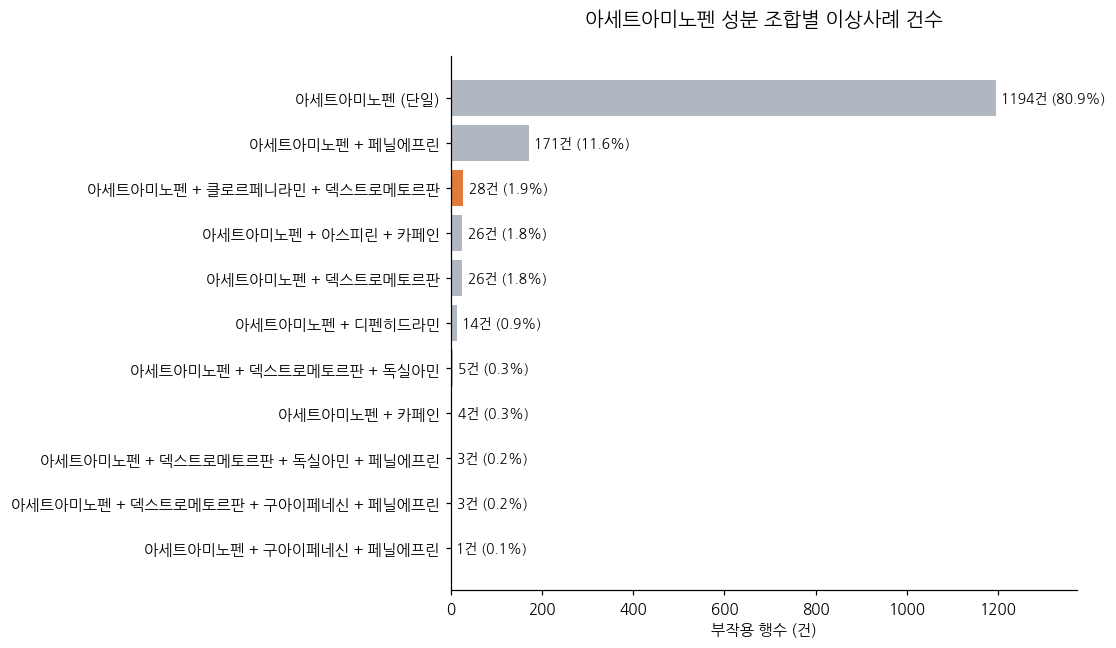



📌 아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판 조합
   = 28건 / 전체 조합 카운트 1475건 = 1.9%
   → 단일(80.9%)·페닐에프린(11.6%)에 이어 복합 조합 중 가장 큰 비중.


In [9]:
# =============================================================================
# 0 : 아세트아미노펜 내 '클로르페니라민+덱스트로메토르판' 조합 비율 그래프
# ==============================================================================
eng_to_set = {eng: cset for cset, (eng, kor) in LABEL_KOR.items()}

group_counts = {LABEL_KOR[eng_to_set[eng]][1]: len(combo_groups[eng]) for eng in combo_groups}
total_cnt = sum(group_counts.values())

items = sorted(group_counts.items(), key=lambda x: x[1], reverse=True)
labels = [k for k, v in items]
values = [v for k, v in items]
ratios = [v / total_cnt * 100 for v in values]

colors = ['#E07B39' if lab == target_kor else '#B0B7C0' for lab in labels]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(labels)), values, color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('부작용 행수 (건)')
ax.set_xlim(0, max(values) * 1.15)
ax.set_title('아세트아미노펜 성분 조합별 이상사례 건수', fontsize=13, pad=20)
ax.spines[['top', 'right']].set_visible(False)
for i, (r, v) in enumerate(zip(ratios, values)):
    ax.text(v + max(values) * 0.01, i, f'{v}건 ({r:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print()
print()

tgt_n = group_counts[target_kor]
print(f'📌 아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판 조합')
print(f'   = {tgt_n}건 / 전체 조합 카운트 {total_cnt}건 = {tgt_n/total_cnt*100:.1f}%')
print(f'   → 단일(80.9%)·페닐에프린(11.6%)에 이어 복합 조합 중 가장 큰 비중.')

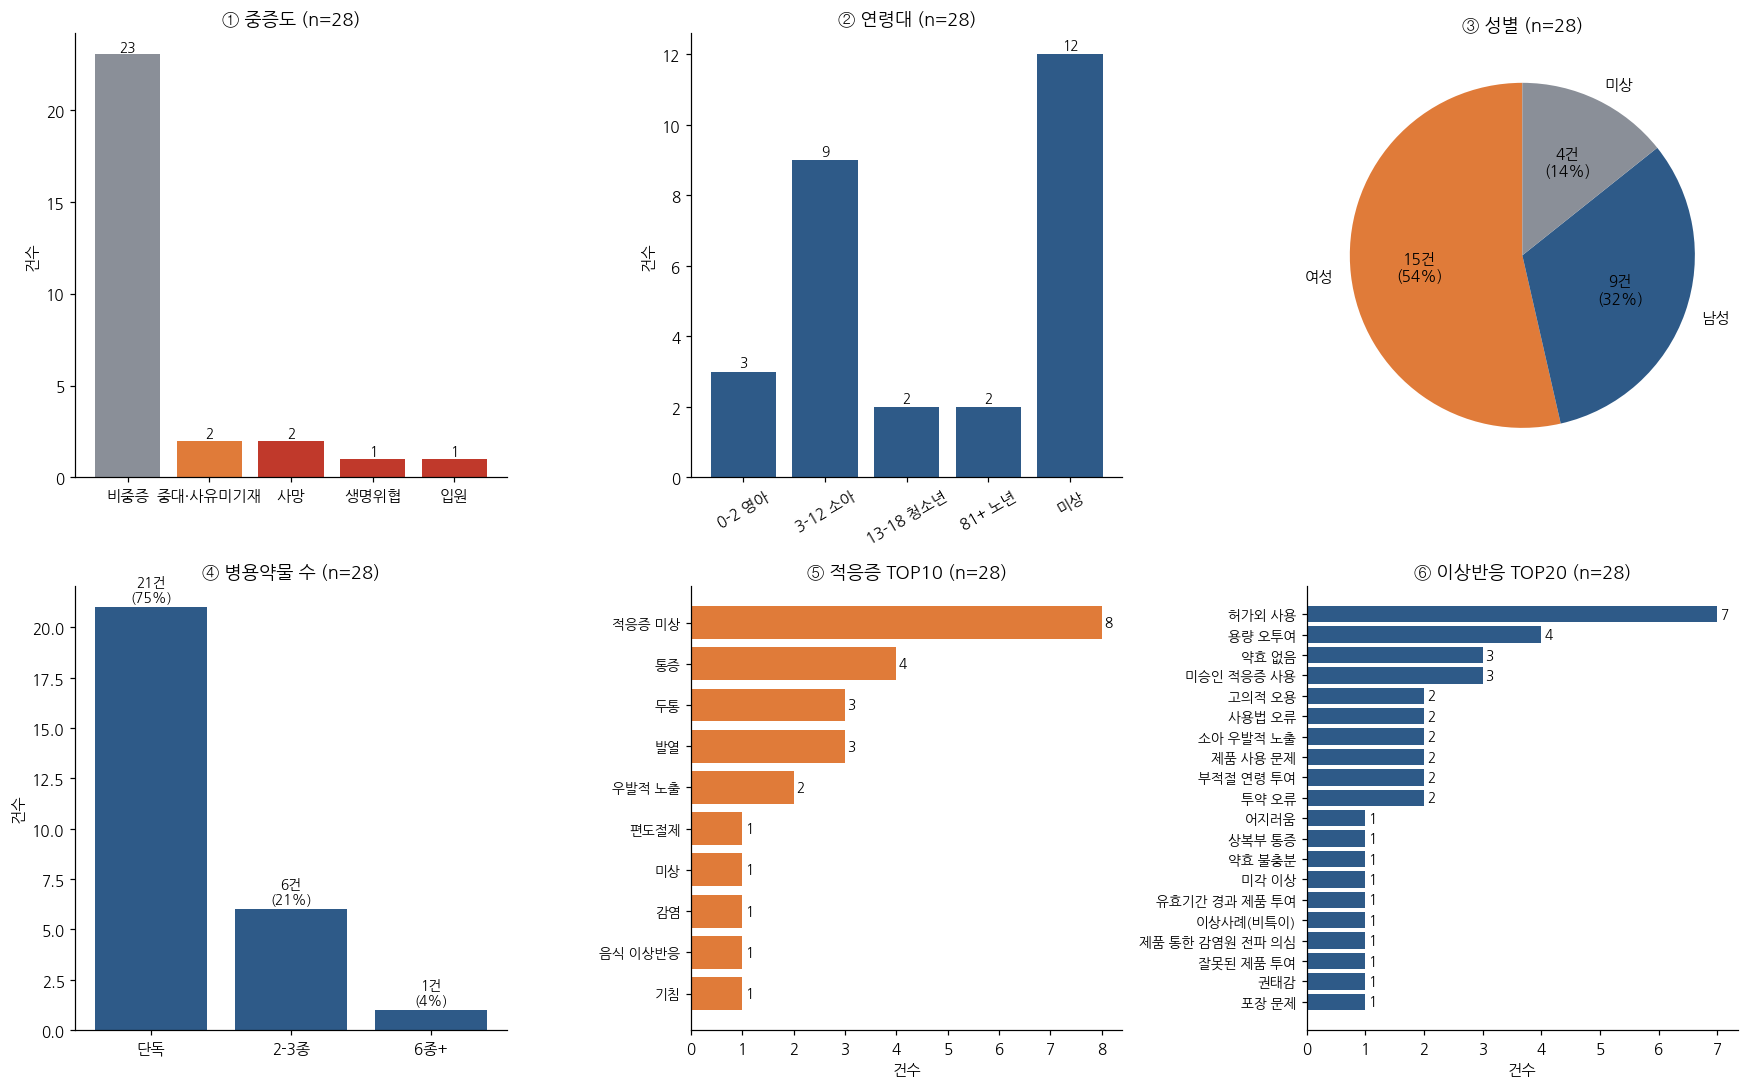



📌 참고: '중대·사유미기재' 2건은 serious='Yes'로 보고됐으나
   serious_flags에 구체적 사유(사망/입원/생명위협 등)가 기록되지 않은 행입니다.
   임의로 특정 사유를 추정하지 않고, 있는 그대로 별도 항목으로 표시했습니다.


In [10]:
# ============================================================
# 1 : 조합군 내부 분석 (n=28)  ※ 전체 비교 없이 조합군 내부 분포만
# ------------------------------------------------------------
# 항목: 중증도 / 연령대 / 성별 / 병용약물 수 / 적응증 / 이상반응 TOP8
# n=28 소표본 → 모든 수치는 '보고 경향(reporting tendency)'
# ============================================================
print()
print()

combo = combo_groups['Acetaminophen + Chlorpheniramine + Dextromethorphan'].copy()
N = len(combo)

PALETTE = {'main': '#2E5A88', 'accent': '#E07B39', 'warn': '#C0392B',
           'ok': '#4A9D7F', 'neutral': '#8A8F98'}
SEQ = ['#2E5A88', '#4A78A0', '#E07B39', '#4A9D7F', '#C0392B',
       '#9B7CB6', '#D4A24C', '#6C8EAD']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))


# ---- (1) 중증도 : serious_flags × serious 교차 반영 ----
ax = axes[0, 0]
flag_kor = {
    'Death': '사망', 'Hospitalization': '입원', 'Life-Threatening': '생명위협',
    'Disability': '장애', 'Congenital Anomaly': '선천이상', 'Other': '기타',
}

# 실제 사유가 있는 flag만 집계 (Unknown은 아래에서 별도 처리)
flags = combo['serious_flags'].fillna('').str.split(';').explode().str.strip()
flags = flags[(flags != '') & (flags != 'Unknown')]
fc = flags.value_counts()

# 'Unknown'(사유 미기재) 행을 serious(Yes/No)로 재분리
#  → 원래 '미상' 버킷에 "진짜 비중증"과 "중대인데 사유만 안 적힘"이 섞여 있던 걸 분리
unknown_mask = combo['serious_flags'].fillna('Unknown').str.strip() == 'Unknown'
n_unknown_no  = int(((unknown_mask) & (combo['serious'] == 'No')).sum())
n_unknown_yes = int(((unknown_mask) & (combo['serious'] == 'Yes')).sum())

labels = ['비중증', '중대·사유미기재'] + [flag_kor.get(i, i) for i in fc.index]
values = [n_unknown_no, n_unknown_yes] + list(fc.values)
colors = [PALETTE['neutral'], PALETTE['accent']] + [PALETTE['warn']] * len(fc)

order = np.argsort(values)[::-1]
labels = [labels[i] for i in order]
values = [values[i] for i in order]
colors = [colors[i] for i in order]

ax.bar(labels, values, color=colors)
ax.set_ylabel('건수')
ax.set_title(f'① 중증도 (n={N})')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(values):
    if v > 0:
        ax.text(i, v + 0.2, str(int(v)), ha='center', fontsize=9)

# ---- (2) 연령대 ----
ax = axes[0, 1]
age_map = {'Infant(0-2)': '0-2 영아', 'Child(3-12)': '3-12 소아', 'Teen(13-18)': '13-18 청소년',
           'Adult(19-40)': '19-40 성인', 'Middle-Aged(41-65)': '41-65 중년', 'Senior(66-80)': '66-80 장년',
           'Elderly(81+)': '81+ 노년', 'Unknown': '미상'}
ag = combo['age_group'].value_counts()
ag = ag.reindex([k for k in age_map if k in ag.index])
ax.bar([age_map[i] for i in ag.index], ag.values, color=PALETTE['main'])
ax.set_ylabel('건수'); ax.set_title(f'② 연령대 (n={N})')
ax.tick_params(axis='x', rotation=30)
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(ag.values):
    ax.text(i, v + 0.15, str(int(v)), ha='center', fontsize=9)

# ---- (3) 성별 ----
ax = axes[0, 2]
sx = combo['patient_sex'].value_counts().reindex(['Female', 'Male', 'Unknown']).fillna(0)
sx_kor = ['여성', '남성', '미상']
ax.pie(sx.values, labels=sx_kor, colors=[PALETTE['accent'], PALETTE['main'], PALETTE['neutral']],
       autopct=lambda p: f'{int(round(p/100*N))}건\n({p:.0f}%)', startangle=90)
ax.set_title(f'③ 성별 (n={N})')

# ---- (4) 병용약물 수 ----
ax = axes[1, 0]
dc_map = {'Single': '단독', '2-3 Drugs': '2-3종', '4-5 Drugs': '4-5종', 'Polypharmacy(6+)': '6종+'}
dc = combo['drug_count_category'].value_counts()
dc = dc.reindex([k for k in dc_map if k in dc.index])
ax.bar([dc_map[i] for i in dc.index], dc.values, color=PALETTE['main'])
ax.set_ylabel('건수'); ax.set_title(f'④ 병용약물 수 (n={N})')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(dc.values):
    ax.text(i, v + 0.3, f'{int(v)}건\n({v/N*100:.0f}%)', ha='center', fontsize=9)

# ---- (5) 적응증 TOP10 ----
ax = axes[1, 1]
ind_kor = {'Product Used For Unknown Indication': '적응증 미상', 'Pain': '통증',
           'Headache': '두통', 'Pyrexia': '발열', 'Accidental Exposure To Product': '우발적 노출',
           'Unknown': '미상', 'Tonsillectomy': '편도절제', 'Infection': '감염',
           'Adverse Food Reaction': '음식 이상반응', 'Cough': '기침'}
ind = combo['drug_indication'].value_counts().head(10)
ax.barh(range(len(ind)), ind.values, color=PALETTE['accent'])
ax.set_yticks(range(len(ind)))
ax.set_yticklabels([ind_kor.get(i, i) for i in ind.index], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('건수'); ax.set_title(f'⑤ 적응증 TOP10 (n={N})')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(ind.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)

# ---- (6) 이상반응 TOP20 ----
ax = axes[1, 2]
react_kor = {
        'Off label use': '허가외 사용',
        'Incorrect dose administered': '용량 오투여',
        'Drug ineffective': '약효 없음',
        'Product use in unapproved indication': '미승인 적응증 사용',
        'Product use issue': '제품 사용 문제',
        'Wrong technique in product usage process': '사용법 오류',
        'Accidental exposure to product by child': '소아 우발적 노출',
        'Product administered to patient of inappropriate age': '부적절 연령 투여',
        'Intentional product misuse': '고의적 오용',
        'Product administration error': '투약 오류',
        'Dizziness': '어지러움',
        'Adverse event': '이상사례(비특이)',
    }
react_kor.update({
    'Abdominal pain upper': '상복부 통증',
    'Drug effect incomplete': '약효 불충분',
    'Dysgeusia': '미각 이상',
    'Expired product administered': '유효기간 경과 제품 투여',
    'Suspected transmission of an infectious agent via product': '제품 통한 감염원 전파 의심',
    'Wrong product administered': '잘못된 제품 투여',
    'Malaise': '권태감',
    'Product packaging issue': '포장 문제',
})
r = combo['reactions'].fillna('').str.split(';').explode().str.strip()
r = r[r != '']
top_r = r.value_counts().head(20)
ax.barh(range(len(top_r)), top_r.values, color=PALETTE['main'])
ax.set_yticks(range(len(top_r)))
ax.set_yticklabels([react_kor.get(x, x) for x in top_r.index], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('건수'); ax.set_title(f'⑥ 이상반응 TOP20 (n={N})')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(top_r.values):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print()
print()
print(f'''📌 참고: '중대·사유미기재' {n_unknown_yes}건은 serious='Yes'로 보고됐으나
   serious_flags에 구체적 사유(사망/입원/생명위협 등)가 기록되지 않은 행입니다.
   임의로 특정 사유를 추정하지 않고, 있는 그대로 별도 항목으로 표시했습니다.''')


In [11]:
# ============================================================
# 셀 3 : 인사이트 요약 (한국어)  ※ 조합군 내부 기준
# ============================================================
nonser = (combo['serious'] == 'No').mean() * 100
child_n = combo['age_group'].isin(['Child(3-12)', 'Infant(0-2)']).sum()
single = (combo['drug_count_category'] == 'Single').mean() * 100
female = (combo['patient_sex'] == 'Female').mean() * 100

print(f'''
────────────────────────────────────────────────────
【인사이트 요약】 아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판 (n={N})
※ 조합군 내부 분포 기준 · n={N} 소표본 → '보고 경향'으로만 해석
────────────────────────────────────────────────────


① 중증도(serious_flags)
    · 28건 중 25건이 '미상(Unknown)', 중대 플래그는 사망 2·입원 1·생명위협 1건.
    → 대부분 결과가 미기재이며, 명시된 중대 사례는 소수. 경증/미상 보고가 우세.

② 연령대
   · 소아+영아 {child_n}건({child_n/N*100:.0f}%)으로 최다, 성인·노인은 소수.
   → 소아용 복합 감기약(Children's TYLENOL 계열)이 보고를 주도.


③ 성별
   · 여성 {female:.0f}%로 다소 우세하나 남성과 큰 격차는 아님.
   → 성별 편중은 뚜렷하지 않음.

④ 병용약물 수
   · 단독 복용 {single:.0f}%로 대부분.
   → 다른 약과 병용보다 이 제품 단독 사용 상황에서 주로 보고됨.

⑤ 적응증
   · '적응증 미상'이 최다, 이어 통증·두통·발열 등 감기 관련 증상.
   → 감기약 용도로 쓰이나 기재 미비(미상)가 많아 해석에 한계.

⑥ 이상반응 TOP8  ★핵심 신호
   · 상위가 약리 부작용이 아니라 '허가외 사용·용량 오투여·소아 우발노출·
     부적절 연령 투여' 등 사용 오류(medication error) 계열에 집중.
   → 안전 개입 우선순위는 성분 독성보다 라벨/포장/보호자 투약 교육.

【종합】
소아 대상 + 사용 오류 중심의 조합. 성분 자체의 중증 신호는 약하고,
'잘못 쓰는 방식'에서 이상사례가 보고되는 경향. 단 n={N} 소표본 +
FAERS 자발보고(선택편향·true negative 부재)이므로 인과가 아닌 보고 경향.
────────────────────────────────────────────────────
''')




────────────────────────────────────────────────────
【인사이트 요약】 아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판 (n=28)
※ 조합군 내부 분포 기준 · n=28 소표본 → '보고 경향'으로만 해석
────────────────────────────────────────────────────


① 중증도(serious_flags)
    · 28건 중 25건이 '미상(Unknown)', 중대 플래그는 사망 2·입원 1·생명위협 1건.
    → 대부분 결과가 미기재이며, 명시된 중대 사례는 소수. 경증/미상 보고가 우세.

② 연령대
   · 소아+영아 12건(43%)으로 최다, 성인·노인은 소수.
   → 소아용 복합 감기약(Children's TYLENOL 계열)이 보고를 주도.


③ 성별
   · 여성 54%로 다소 우세하나 남성과 큰 격차는 아님.
   → 성별 편중은 뚜렷하지 않음.

④ 병용약물 수
   · 단독 복용 75%로 대부분.
   → 다른 약과 병용보다 이 제품 단독 사용 상황에서 주로 보고됨.

⑤ 적응증
   · '적응증 미상'이 최다, 이어 통증·두통·발열 등 감기 관련 증상.
   → 감기약 용도로 쓰이나 기재 미비(미상)가 많아 해석에 한계.

⑥ 이상반응 TOP8  ★핵심 신호
   · 상위가 약리 부작용이 아니라 '허가외 사용·용량 오투여·소아 우발노출·
     부적절 연령 투여' 등 사용 오류(medication error) 계열에 집중.
   → 안전 개입 우선순위는 성분 독성보다 라벨/포장/보호자 투약 교육.

【종합】
소아 대상 + 사용 오류 중심의 조합. 성분 자체의 중증 신호는 약하고,
'잘못 쓰는 방식'에서 이상사례가 보고되는 경향. 단 n=28 소표본 +
FAERS 자발보고(선택편향·true negative 부재)이므로 인과가 아닌 보고 경향.
────────────────────────────────────────────────────



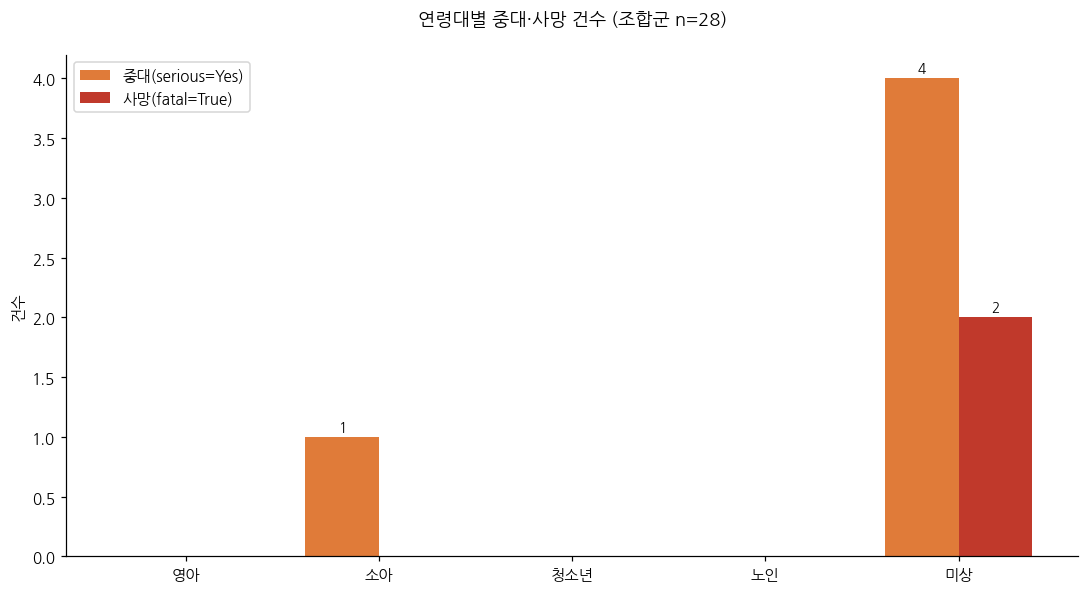



📌 인사이트 | 연령대별 중대·사망
· 조합군 28건 중 중대 5건·사망 2건으로 절대수가 매우 적음.
· 중대·사망 사례 대부분이 '미상' 연령에 몰려 있고,
  연령이 확인된 소아·영아·청소년에서는 중대/사망 보고가 거의 없음.
→ 연령별 중증도 차이를 논하기엔 사건 수가 부족(n 부족). 보고 경향으로만 참고.


In [12]:
# ============================================================
# 1-1 : 연령대별 중대(serious) / 사망(fatal) 건수
# ============================================================
combo = combo.reset_index(drop=True)   # explode/crosstab 인덱스 중복 방지
N = len(combo)

age_map = {'Infant(0-2)': '영아', 'Child(3-12)': '소아', 'Teen(13-18)': '청소년',
           'Adult(19-40)': '성인', 'Middle-Aged(41-65)': '중년', 'Senior(66-80)': '장년',
           'Elderly(81+)': '노인', 'Unknown': '미상'}
age_order = [k for k in age_map if k in combo['age_group'].unique()]

serious_by_age = combo[combo['serious'] == 'Yes']['age_group'].value_counts().reindex(age_order).fillna(0)
fatal_by_age   = combo[combo['is_fatal'] == True]['age_group'].value_counts().reindex(age_order).fillna(0)

x = np.arange(len(age_order)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, serious_by_age.values, w, label='중대(serious=Yes)', color='#E07B39')
ax.bar(x + w/2, fatal_by_age.values,   w, label='사망(fatal=True)',  color='#C0392B')
ax.set_xticks(x); ax.set_xticklabels([age_map[a] for a in age_order])
ax.set_ylabel('건수'); ax.set_title(f'연령대별 중대·사망 건수 (조합군 n={N})', pad=20)
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(serious_by_age.values):
    if v > 0: ax.text(i - w/2, v + 0.05, str(int(v)), ha='center', fontsize=9)
for i, v in enumerate(fatal_by_age.values):
    if v > 0: ax.text(i + w/2, v + 0.05, str(int(v)), ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print()
print()

print(f'''📌 인사이트 | 연령대별 중대·사망
· 조합군 {N}건 중 중대 5건·사망 2건으로 절대수가 매우 적음.
· 중대·사망 사례 대부분이 '미상' 연령에 몰려 있고,
  연령이 확인된 소아·영아·청소년에서는 중대/사망 보고가 거의 없음.
→ 연령별 중증도 차이를 논하기엔 사건 수가 부족(n 부족). 보고 경향으로만 참고.''')

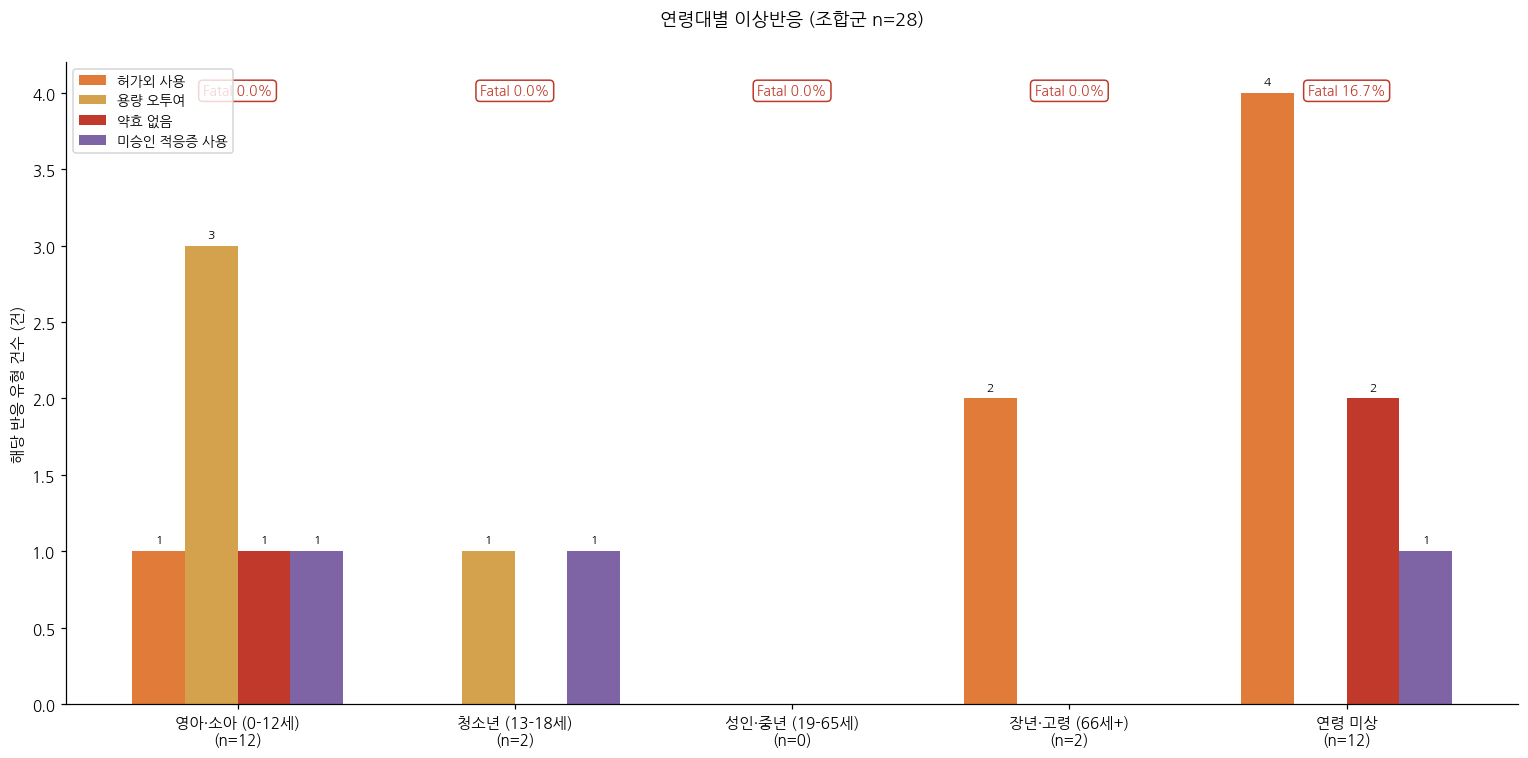



📌 인사이트 | 연령대별 이상반응 TOP4 (조합군 n=28)
· 영아·소아(n=12): '용량 오투여'가 두드러짐 → 소아 투약 계량 오류 신호.
· 장년·고령(n=2): 소수지만 전부 '허가외 사용'.
· 성인·중년(n=0): 조합군 내 사례 없음 — 막대 자체가 존재하지 않음.
· 연령 미상(n=12, 전체의 43%): 가장 큰 그룹이지만
  연령 정보가 없어 앞의 세 밴드와 직접 비교는 불가 — 참고용으로만 병기.
→ 앞선 버전은 '연령 미상' 12건(43%)이 밴드 목록에서 빠져 있어 전체 그림의 절반 가까이가
  그래프에 나타나지 않는 상태였음. 또한 밴드별 n=0~12로 극히 작아 %보다는
  raw count로 보는 것이 착시(예: n=2에서 "100%")를 줄여줌.


In [13]:
# ============================================================
# 1-3 연령대별 이상반응 (조합군 기준, '미상' 연령대 포함 / raw count)
# ------------------------------------------------------------
# 조합군(아세트아미노펜+클로르페니라민+덱스트로메토르판, n=28)
# ※ 각 연령밴드 n이 매우 작고(0~12건), '미상'만 12건으로 가장 커서
#    %가 아닌 건수로 표시 — 해석은 '보고 경향' 참고용
# ============================================================
combo = combo.reset_index(drop=True)
N = len(combo)

# --- 연령밴드 정의 ('미상'을 별도 밴드로 명시 포함) ---
def to_band(a):
    if a in ['Infant(0-2)', 'Child(3-12)']:            return '영아·소아\t(0-12세)'
    if a == 'Teen(13-18)':                              return '청소년\t(13-18세)'
    if a in ['Adult(19-40)', 'Middle-Aged(41-65)']:    return '성인·중년\t(19-65세)'
    if a in ['Senior(66-80)', 'Elderly(81+)']:         return '장년·고령\t(66세+)'
    return '연령 미상'

combo['band'] = combo['age_group'].apply(to_band)
band_order = ['영아·소아\t(0-12세)', '청소년\t(13-18세)', '성인·중년\t(19-65세)',
              '장년·고령\t(66세+)', '연령 미상']   # ← '연령 미상' 추가

# --- 이상반응 분해 후 TOP4 선정 ---
r = (combo.assign(reaction=combo['reactions'].fillna('').str.split(';'))
          .explode('reaction').reset_index(drop=True))
r['reaction'] = r['reaction'].str.strip()
r = r[r['reaction'] != '']
r['band'] = r['age_group'].apply(to_band)

top4 = r['reaction'].value_counts().head(4).index.tolist()
react_kor = {
    'Off label use': '허가외 사용',
    'Incorrect dose administered': '용량 오투여',
    'Drug ineffective': '약효 없음',
    'Product use in unapproved indication': '미승인 적응증 사용',
}

# --- 밴드 x TOP4 건수 (raw count, % 아님) ---
ct = pd.crosstab(r['band'], r['reaction']).reindex(index=band_order, columns=top4).fillna(0)
band_n = combo['band'].value_counts().reindex(band_order).fillna(0)

# --- 그래프 ---
COLORS = ['#E07B39', '#D4A24C', '#C0392B', '#7E64A5']
x = np.arange(len(band_order)); w = 0.19

fig, ax = plt.subplots(figsize=(14, 7))
for j, reac in enumerate(top4):
    vals = ct[reac].values
    bars = ax.bar(x + (j - 1.5) * w, vals, w,
                  label=react_kor.get(reac, reac), color=COLORS[j])
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(x[i] + (j - 1.5) * w, v + 0.05, f'{int(v)}', ha='center', fontsize=8)

# --- 상단 Fatal % 표기 (모든 밴드, '미상' 포함) ---
for i, b in enumerate(band_order):
    sub = combo[combo['band'] == b]
    fatal = (sub['is_fatal'] == True).mean() * 100 if len(sub) else 0
    ax.text(x[i], ax.get_ylim()[1] * 0.95, f'Fatal {fatal:.1f}%',
            ha='center', fontsize=9, color='#C0392B',
            bbox=dict(boxstyle='round', fc='white', ec='#C0392B'))

ax.set_xticks(x)
ax.set_xticklabels([f'{b}\n(n={int(band_n.iloc[i])})' for i, b in enumerate(band_order)])
ax.set_ylabel('해당 반응 유형 건수 (건)')
ax.set_title(f'연령대별 이상반응 (조합군 n={N})', pad=25)
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print()
print()

# --- 밴드별 n을 변수로 미리 추출 (라벨 문자열 재입력으로 인한 오류 방지) ---
n_child   = int(band_n.loc[band_order[0]])   # 영아·소아
n_teen    = int(band_n.loc[band_order[1]])   # 청소년
n_adult   = int(band_n.loc[band_order[2]])   # 성인·중년
n_elderly = int(band_n.loc[band_order[3]])   # 장년·고령
n_unknown = int(band_n.loc[band_order[4]])   # 연령 미상

print(f'''📌 인사이트 | 연령대별 이상반응 TOP4 (조합군 n={N})
· 영아·소아(n={n_child}): '용량 오투여'가 두드러짐 → 소아 투약 계량 오류 신호.
· 장년·고령(n={n_elderly}): 소수지만 전부 '허가외 사용'.
· 성인·중년(n={n_adult}): 조합군 내 사례 없음 — 막대 자체가 존재하지 않음.
· 연령 미상(n={n_unknown}, 전체의 {n_unknown/N*100:.0f}%): 가장 큰 그룹이지만
  연령 정보가 없어 앞의 세 밴드와 직접 비교는 불가 — 참고용으로만 병기.
→ 앞선 버전은 '연령 미상' 12건(43%)이 밴드 목록에서 빠져 있어 전체 그림의 절반 가까이가
  그래프에 나타나지 않는 상태였음. 또한 밴드별 n=0~12로 극히 작아 %보다는
  raw count로 보는 것이 착시(예: n=2에서 "100%")를 줄여줌.''')



## **브랜드별**
목록/연령분포/사망건수

이 조합 브랜드 '언급' 총 54건 (조합군 리포트 28건 중 일부는 브랜드가 겹쳐 있음)




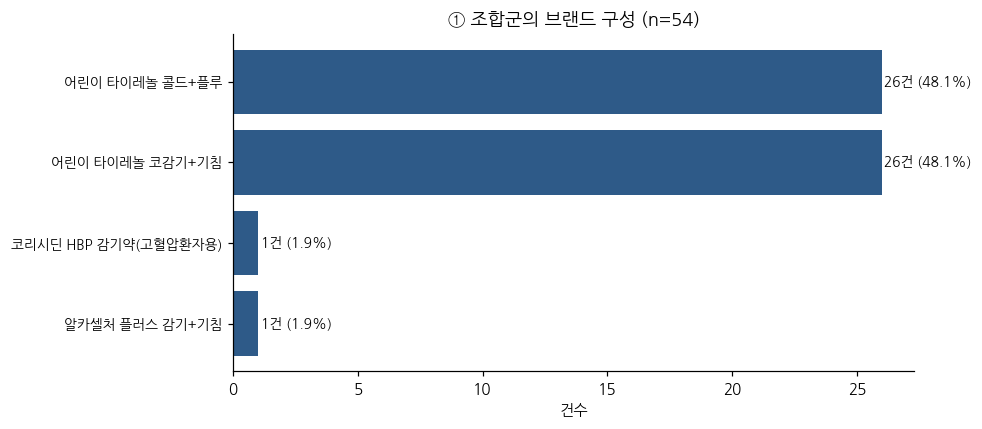

📌 '어린이 타이레놀 콜드+플루'가 26건(48.1%)으로 이 조합 보고를 사실상 독점 → '조합군 특성'이라기보다 이 한 브랜드의 특성에 가까움.
                      영아  소아  청소년  성인  중년  장년  노인  미상
알카셀처 플러스 감기+기침         0   0    0   0   0   0   0   1
어린이 타이레놀 코감기+기침        3   9    2   0   0   0   2  10
어린이 타이레놀 콜드+플루         3   9    2   0   0   0   2  10
코리시딘 HBP 감기약(고혈압환자용)   0   0    0   0   0   0   0   1


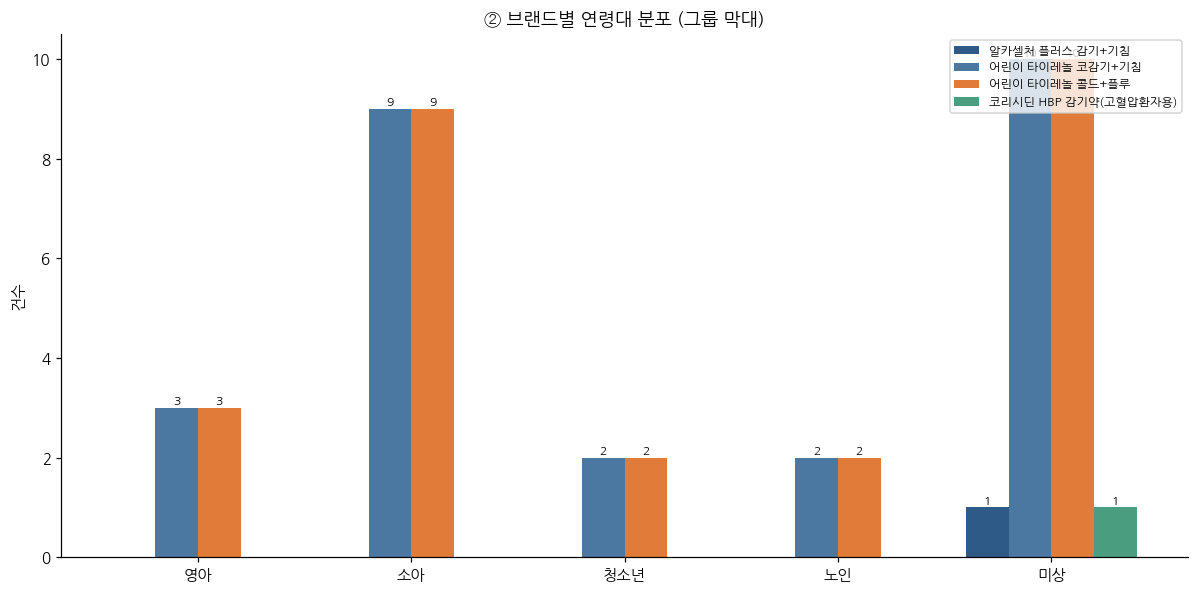

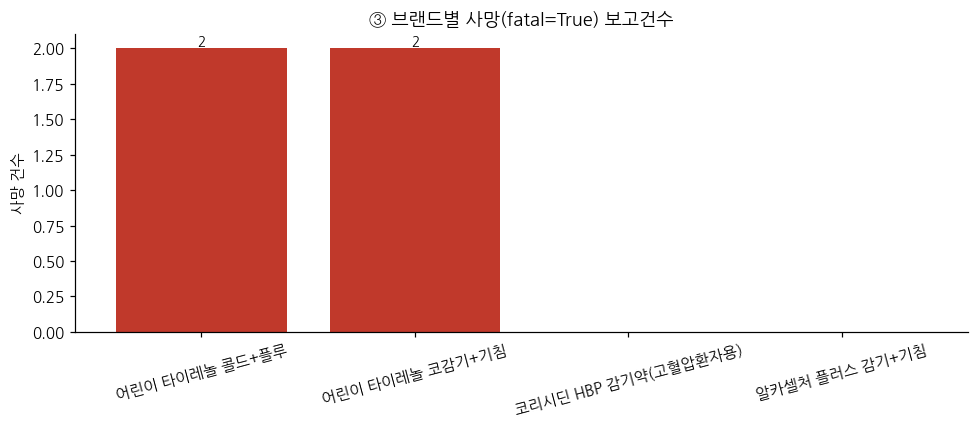

📌 사망 4건 모두 '어린이 타이레놀 콜드+플루', 성별: ['Male', 'Male', 'Male', 'Male']

────────────────────────────────────────────────────
【노트북에 없던 인사이트 1~4】
────────────────────────────────────────────────────
1. 브랜드 집중: 보고 54건 중 26건(48.1%)이
   '어린이 타이레놀 콜드+플루' 단일 브랜드 → "조합군의 특성"이 아니라
   사실상 "이 한 브랜드의 특성"에 가까움.

2. 소아 심각도 재확인: 확인된 소아(Child 3-12세) 9건 중
   중대(serious=Yes)는 1건(11%)뿐.
   → "소아가 다수"라는 것과 "소아가 위험하다"는 것은 다른 이야기.

3. 사망 사례 프로필: 사망 4건 모두
   '어린이 타이레놀 콜드+플루' + 성별 ['Male', 'Male', 'Male', 'Male']
   → 제품명은 소아용인데 연령이 기록되지 않은 데이터 공백 상태에서 발생.

4. 알카셀처 플러스(유일한 성인 지향 브랜드): 1건 보고, 이 조합 내에서
   가장 심각한 결과(입원+생명위협 동시)를 기록 → n=1이라 일반화는 어렵지만
   "소아용 제품군 속 유일한 성인용 브랜드가 가장 위험한 결과"라는 점은 주목할 만함.
────────────────────────────────────────────────────



In [14]:
# ============================================================
# 2  :  브랜드 단위 분석 준비
# ------------------------------------------------------------
# 한 행의 brand_name/전체_활성성분에는 이 조합과 무관한 다른 성분의 브랜드도
# 같이 적혀 있을 수 있어, parse_combos와 동일 로직으로 '성분세트==이 조합'인
# 브랜드만 정확히 골라낸다.
# ============================================================
target_set = eng_to_set[target_eng]

BRAND_KOR = {
    'CORICIDIN HBP COLD AND FLU': '코리시딘 HBP 감기약(고혈압환자용)',
    'CHILDRENS TYLENOL COLD PLUS FLU': '어린이 타이레놀 콜드+플루',
    'CHILDRENS TYLENOL COLD PLUS COUGH PLUS RUNNY NOSE': '어린이 타이레놀 코감기+기침',
    'ALKA-SELTZER PLUS COLD AND COUGH': '알카셀처 플러스 감기+기침',
}
def kor(b):
    return BRAND_KOR.get(b, b)

def brands_in_target_combo(text):
    if pd.isna(text):
        return []
    out = []
    for seg in str(text).split(';'):
        if ':' not in seg:
            continue
        brand, body = seg.split(':', 1)
        if not re.search('Acetaminophen', body, re.IGNORECASE):
            continue
        comp = frozenset(k for k in COMPANION_INGS if re.search(k, body, re.IGNORECASE))
        if comp == target_set:
            out.append(brand.strip())
    return out

records = []
for _, row in combo.iterrows():
    for b in brands_in_target_combo(row['전체_활성성분']):
        records.append({'brand': b, 'age_group': row['age_group'],
                         'sex': row['patient_sex'], 'serious': row['serious'],
                         'is_fatal': row['is_fatal']})
brand_df = pd.DataFrame(records)
print(f"이 조합 브랜드 '언급' 총 {len(brand_df)}건 (조합군 리포트 {N}건 중 일부는 브랜드가 겹쳐 있음)")
print()
print()


# ---- ① 조합군의 브랜드 ----
brand_counts = brand_df['brand'].value_counts()
brand_pct = (brand_counts / brand_counts.sum() * 100).round(1)
brand_labels_kor = [kor(b) for b in brand_counts.index]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(range(len(brand_counts)), brand_counts.values, color=PALETTE['main'])
ax.set_yticks(range(len(brand_counts))); ax.set_yticklabels(brand_labels_kor, fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('건수')
ax.set_title(f'① 조합군의 브랜드 구성 (n={len(brand_df)})')
ax.spines[['top', 'right']].set_visible(False)
for i, (c, p) in enumerate(zip(brand_counts.values, brand_pct.values)):
    ax.text(c + 0.1, i, f'{c}건 ({p}%)', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(f"📌 '{kor(brand_counts.index[0])}'가 {brand_counts.iloc[0]}건({brand_pct.iloc[0]}%)으로 이 조합 보고를 사실상 독점"
      f" → '조합군 특성'이라기보다 이 한 브랜드의 특성에 가까움.")


# ---- ② 브랜드별 연령별 사용 빈도 (그룹 막대, 누적 아님) ----
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']
age_kor_map = {'Infant(0-2)': '영아', 'Child(3-12)': '소아', 'Teen(13-18)': '청소년',
               'Adult(19-40)': '성인', 'Middle-Aged(41-65)': '중년', 'Senior(66-80)': '장년',
               'Elderly(81+)': '노인', 'Unknown': '미상'}

age_by_brand = pd.crosstab(brand_df['brand'], brand_df['age_group']).reindex(columns=age_order).fillna(0).astype(int)
age_by_brand.columns = [age_kor_map[c] for c in age_by_brand.columns]
age_by_brand.index = [kor(b) for b in age_by_brand.index]
print(age_by_brand)

# 값이 하나라도 있는 연령대만 x축에 표시 (0으로만 채워진 열은 제외)
age_cols_nonzero = [c for c in age_by_brand.columns if age_by_brand[c].sum() > 0]
brands_list = age_by_brand.index.tolist()
n_brands = len(brands_list)

x = np.arange(len(age_cols_nonzero))
w = 0.8 / n_brands

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, b in enumerate(brands_list):
    vals = age_by_brand.loc[b, age_cols_nonzero].values
    offset = (i - (n_brands - 1) / 2) * w
    ax.bar(x + offset, vals, w, label=b, color=SEQ[i % len(SEQ)])
    for xi, v in zip(x, vals):
        if v > 0:
            ax.text(xi + offset, v + 0.05, str(int(v)), ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(age_cols_nonzero)
ax.set_ylabel('건수'); ax.set_title('② 브랜드별 연령대 분포 (그룹 막대)')
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


# ---- ③ 브랜드별 사망 보고건수 ----
death_by_brand = brand_df[brand_df['is_fatal'] == True]['brand'].value_counts()
death_by_brand = death_by_brand.reindex(brand_counts.index).fillna(0).astype(int)
death_labels_kor = [kor(b) for b in death_by_brand.index]

fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE['warn'] if v > 0 else PALETTE['neutral'] for v in death_by_brand.values]
ax.bar(death_labels_kor, death_by_brand.values, color=colors)
ax.set_ylabel('사망 건수'); ax.set_title('③ 브랜드별 사망(fatal=True) 보고건수')
ax.tick_params(axis='x', rotation=15)
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(death_by_brand.values):
    if v > 0:
        ax.text(i, v + 0.02, str(int(v)), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

fatal_rows = brand_df[brand_df['is_fatal'] == True]
if len(fatal_rows):
    print(f"📌 사망 {len(fatal_rows)}건 모두 '{kor(fatal_rows['brand'].unique()[0])}', 성별: {fatal_rows['sex'].tolist()}")


# ============================================================
# ④ 노트북에 없던 인사이트 1~4 (브랜드 단위 심층분석)
# ============================================================
n_child_known = int((combo['age_group'] == 'Child(3-12)').sum())
child_serious = combo[(combo['age_group'] == 'Child(3-12)') & (combo['serious'] == 'Yes')]
alka = brand_df[brand_df['brand'].str.contains('ALKA', case=False)]

print(f'''
────────────────────────────────────────────────────
【노트북에 없던 인사이트 1~4】
────────────────────────────────────────────────────
1. 브랜드 집중: 보고 {len(brand_df)}건 중 {brand_counts.iloc[0]}건({brand_pct.iloc[0]}%)이
   '{kor(brand_counts.index[0])}' 단일 브랜드 → "조합군의 특성"이 아니라
   사실상 "이 한 브랜드의 특성"에 가까움.

2. 소아 심각도 재확인: 확인된 소아(Child 3-12세) {n_child_known}건 중
   중대(serious=Yes)는 {len(child_serious)}건({len(child_serious)/n_child_known*100:.0f}%)뿐.
   → "소아가 다수"라는 것과 "소아가 위험하다"는 것은 다른 이야기.

3. 사망 사례 프로필: 사망 {len(fatal_rows)}건 모두
   '{kor(fatal_rows["brand"].unique()[0]) if len(fatal_rows) else "-"}' + 성별 {fatal_rows['sex'].tolist()}
   → 제품명은 소아용인데 연령이 기록되지 않은 데이터 공백 상태에서 발생.

4. 알카셀처 플러스(유일한 성인 지향 브랜드): {len(alka)}건 보고, 이 조합 내에서
   가장 심각한 결과(입원+생명위협 동시)를 기록 → n=1이라 일반화는 어렵지만
   "소아용 제품군 속 유일한 성인용 브랜드가 가장 위험한 결과"라는 점은 주목할 만함.
────────────────────────────────────────────────────
''')


리포트 28건 → 브랜드별 분해 합계: 28건 (일치해야 정상)
brand_canon
어린이 타이레놀 감기약 계열(브랜드 특정불가)           26
CORICIDIN HBP COLD AND FLU           1
ALKA-SELTZER PLUS COLD AND COUGH     1
Name: count, dtype: int64


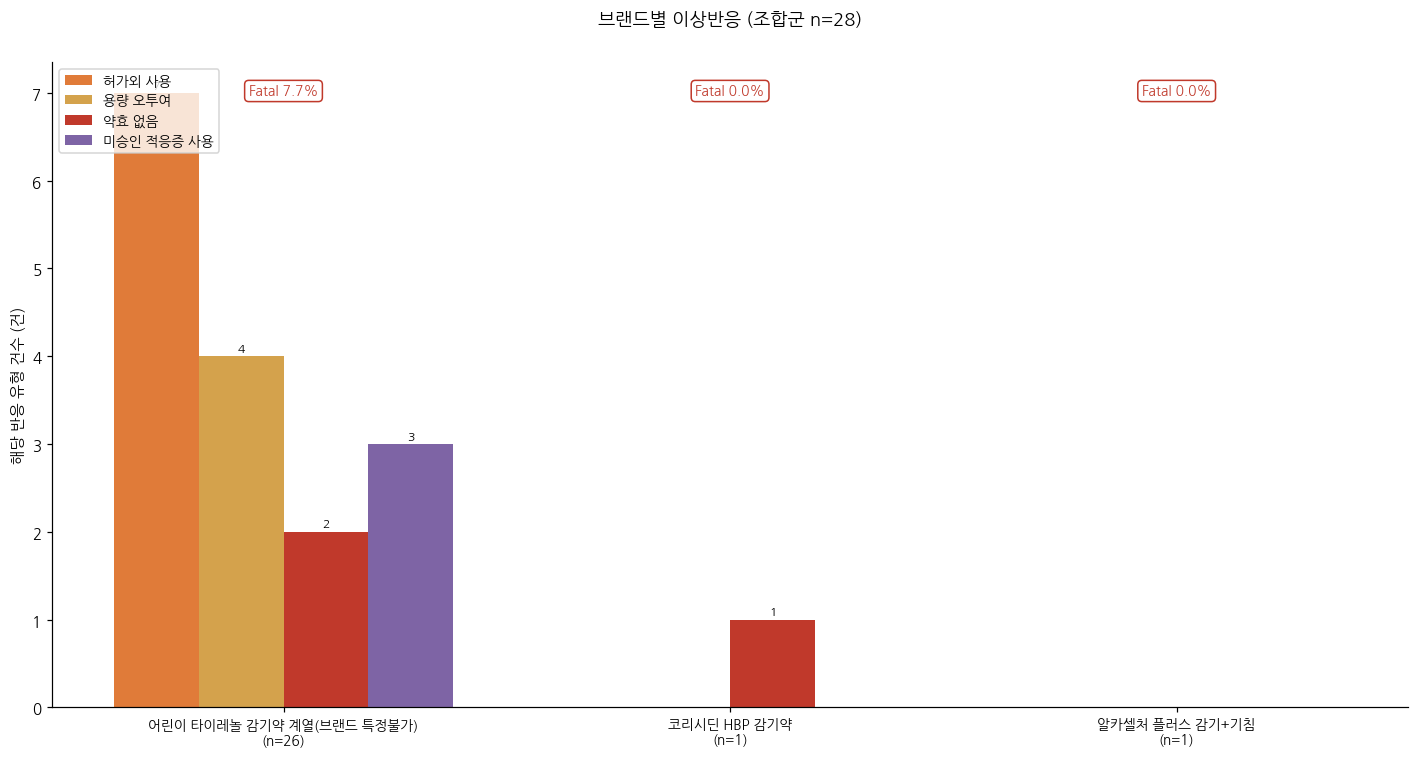



📌 인사이트 | 브랜드별 이상반응 TOP4 (조합군 n=28)
· 브랜드별 리포트 수: {'어린이 타이레놀 감기약 계열(브랜드 특정불가)': np.int64(26), 'CORICIDIN HBP COLD AND FLU': np.int64(1), 'ALKA-SELTZER PLUS COLD AND COUGH': np.int64(1)}
· 어린이 타이레놀 감기약 계열이 26건으로
  이 조합 보고를 사실상 독점 — 브랜드별 비교라기보다 "이 한 브랜드 내부의 반응 분포"에 가까움.
· 코리시딘·알카셀처는 각 1건뿐이라 브랜드 간 비교는 사실상 불가능(표본 부족).
→ 이전 버전(브랜드 미병합)에서는 어린이타이레놀 관련 건수가 전부 2배로 잡혔던
  중복집계 문제를 여기서는 병합으로 해결함.
📌 [보완] 성인·중년(19-65세) 사례가 0건인 이유
· 이 조합 브랜드 구성 자체가 소아용 제품군 위주이기 때문
  ('어린이 타이레놀 감기약 계열(브랜드 특정불가)'이 26/28건(92.9%) 차지).
· 유일하게 성인 지향인 '알카셀처 플러스'조차 age_group='Unknown'으로 기록돼 있어,
  이 조합 데이터 안에는 '연령이 확인된 성인' 사례가 애초에 존재하지 않음.
· 즉 성인·중년 0건은 우연이 아니라 브랜드 포트폴리오의 구조적 결과.


In [15]:
# ============================================================
# 1-4 브랜드별 이상반응 (조합군 기준, 브랜드 중복집계 방지)
# ------------------------------------------------------------
# '어린이 타이레놀 콜드+플루'와 '...코감기+기침'은 이 데이터에서 항상 같은
# 리포트에 같이 붙어 나오는 후보명(브랜드 특정 불가)이라, 그대로 두면 같은
# 사건이 두 브랜드에 중복 집계됨(예: 사망 2건→4건으로 부풀려짐).
# 그래서 이 둘은 하나의 브랜드로 합쳐서 리포트당 브랜드 1개로 고정.
# ============================================================
target_set = eng_to_set[target_eng]

CANONICAL_MERGE = {
    frozenset({'CHILDRENS TYLENOL COLD PLUS FLU', 'CHILDRENS TYLENOL COLD PLUS COUGH PLUS RUNNY NOSE'}):
        '어린이 타이레놀 감기약 계열(브랜드 특정불가)'
}

def brands_in_target_combo(text):
    if pd.isna(text):
        return []
    out = []
    for seg in str(text).split(';'):
        if ':' not in seg:
            continue
        brand, body = seg.split(':', 1)
        if not re.search('Acetaminophen', body, re.IGNORECASE):
            continue
        comp = frozenset(k for k in COMPANION_INGS if re.search(k, body, re.IGNORECASE))
        if comp == target_set:
            out.append(brand.strip())
    return out

def canonical_brand(text):
    raw = brands_in_target_combo(text)
    fs = frozenset(raw)
    if fs in CANONICAL_MERGE:
        return CANONICAL_MERGE[fs]
    return raw[0] if raw else '미상'

BRAND_KOR = {
    'CORICIDIN HBP COLD AND FLU': '코리시딘 HBP 감기약',
    'ALKA-SELTZER PLUS COLD AND COUGH': '알카셀처 플러스 감기+기침',
}
def kor(b):
    return BRAND_KOR.get(b, b)

combo['brand_canon'] = combo['전체_활성성분'].apply(canonical_brand)
brand_n = combo['brand_canon'].value_counts()
print(f"리포트 {N}건 → 브랜드별 분해 합계: {brand_n.sum()}건 (일치해야 정상)")
print(brand_n)

# --- 이상반응 분해 (brand_canon은 explode에도 그대로 유지됨) ---
r = (combo.assign(reaction=combo['reactions'].fillna('').str.split(';'))
          .explode('reaction').reset_index(drop=True))
r['reaction'] = r['reaction'].str.strip()
r = r[r['reaction'] != '']

top4 = r['reaction'].value_counts().head(4).index.tolist()
react_kor = {
    'Off label use': '허가외 사용',
    'Incorrect dose administered': '용량 오투여',
    'Drug ineffective': '약효 없음',
    'Product use in unapproved indication': '미승인 적응증 사용',
}

brand_order = brand_n.sort_values(ascending=False).index.tolist()
ct = pd.crosstab(r['brand_canon'], r['reaction']).reindex(index=brand_order, columns=top4).fillna(0)

# --- 그래프 ---
COLORS = ['#E07B39', '#D4A24C', '#C0392B', '#7E64A5']
x = np.arange(len(brand_order)); w = 0.19

fig, ax = plt.subplots(figsize=(13, 7))
for j, reac in enumerate(top4):
    vals = ct[reac].values
    ax.bar(x + (j - 1.5) * w, vals, w,
           label=react_kor.get(reac, reac), color=COLORS[j])
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(x[i] + (j - 1.5) * w, v + 0.05, f'{int(v)}', ha='center', fontsize=8)

# --- 상단 Fatal % 표기 (브랜드별) ---
for i, b in enumerate(brand_order):
    sub = combo[combo['brand_canon'] == b]
    fatal = (sub['is_fatal'] == True).mean() * 100 if len(sub) else 0
    ax.text(x[i], ax.get_ylim()[1] * 0.95, f'Fatal {fatal:.1f}%',
            ha='center', fontsize=9, color='#C0392B',
            bbox=dict(boxstyle='round', fc='white', ec='#C0392B'))

ax.set_xticks(x)
ax.set_xticklabels([f'{kor(b)}\n(n={int(brand_n[b])})' for b in brand_order], fontsize=9)
ax.set_ylabel('해당 반응 유형 건수 (건)')
ax.set_title(f'브랜드별 이상반응 (조합군 n={N})', pad=25)
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print()
print()

print(f'''📌 인사이트 | 브랜드별 이상반응 TOP4 (조합군 n={N})
· 브랜드별 리포트 수: {dict(brand_n)}
· 어린이 타이레놀 감기약 계열이 {int(brand_n.get('어린이 타이레놀 감기약 계열(브랜드 특정불가)', 0))}건으로
  이 조합 보고를 사실상 독점 — 브랜드별 비교라기보다 "이 한 브랜드 내부의 반응 분포"에 가까움.
· 코리시딘·알카셀처는 각 1건뿐이라 브랜드 간 비교는 사실상 불가능(표본 부족).
→ 이전 버전(브랜드 미병합)에서는 어린이타이레놀 관련 건수가 전부 2배로 잡혔던
  중복집계 문제를 여기서는 병합으로 해결함.''')
# ============================================================
# ⑤ [보완] 연령대별 이상반응 인사이트에 "성인·중년 0건 이유" 추가
# ============================================================
top_brand_name = brand_n.index[0]                    # '어린이 타이레놀 감기약 계열(브랜드 특정불가)'
top_brand_cnt = int(brand_n.iloc[0])                  # 26
top_brand_pct = top_brand_cnt / N * 100               # 26/28 = 92.9%

print(f'''📌 [보완] 성인·중년(19-65세) 사례가 0건인 이유
· 이 조합 브랜드 구성 자체가 소아용 제품군 위주이기 때문
  ('{top_brand_name}'이 {top_brand_cnt}/{N}건({top_brand_pct:.1f}%) 차지).
· 유일하게 성인 지향인 '알카셀처 플러스'조차 age_group='Unknown'으로 기록돼 있어,
  이 조합 데이터 안에는 '연령이 확인된 성인' 사례가 애초에 존재하지 않음.
· 즉 성인·중년 0건은 우연이 아니라 브랜드 포트폴리오의 구조적 결과.''')


## **조합군vs아세트아미노펜+클로르페니라민+데스트로메토르판**

분석 대상: 아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판 (n=28)
대조군: 아세트아미노펜 전체(조합군 제외, n=1220)




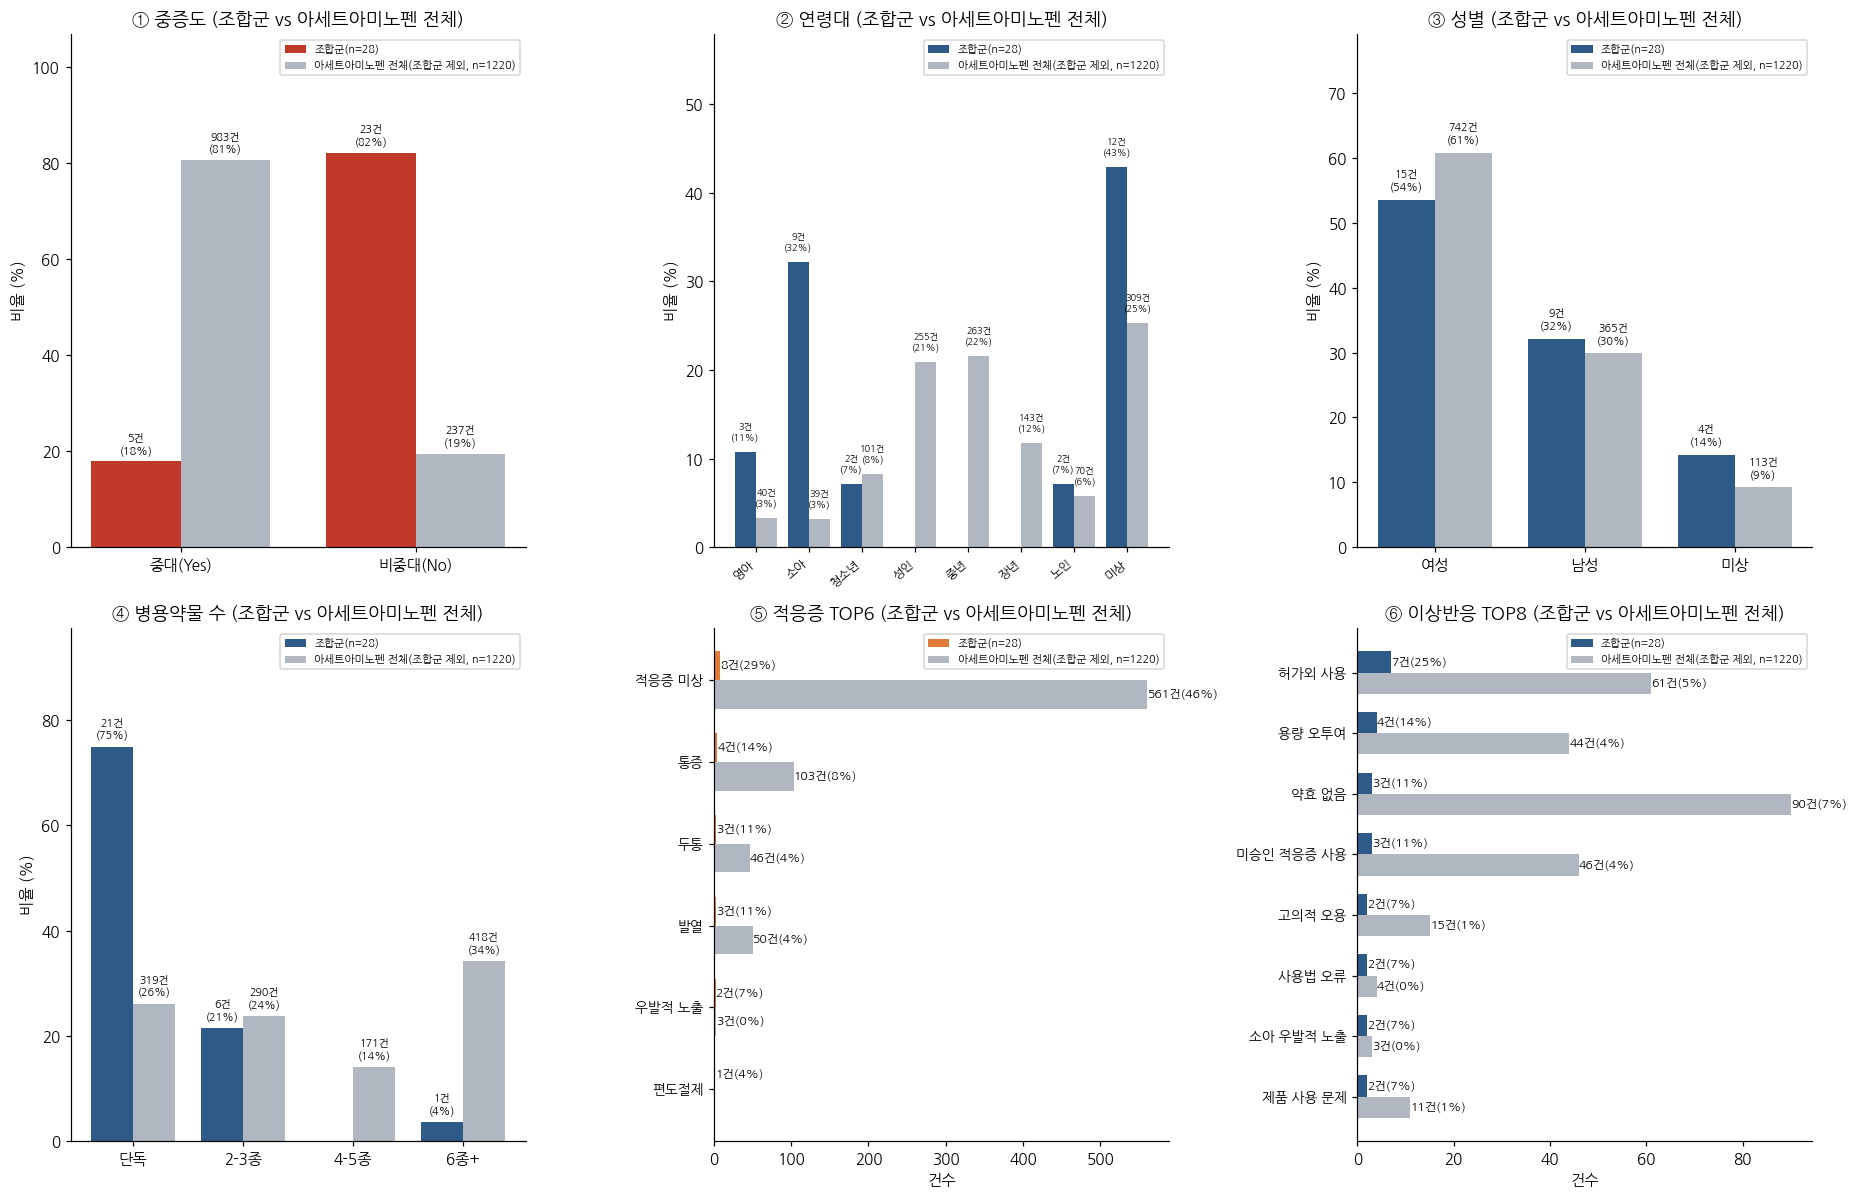




────────────────────────────────────────────────────
【인사이트 요약】 아세트아미노펜 + 클로르페니라민 + 덱스트로메토르판 (n=28)
대조군: 아세트아미노펜 전체(조합군 제외, n=1220)
────────────────────────────────────────────────────

① 중증도  [조합군 vs 아세트아미노펜 전체]
   · 비중대(No) 82%  vs  대조군 19%
   → 조합군이 여전히 훨씬 더 경증 위주(대조군은 여전히 중대 사례가 다수).

② 연령대  [조합군 vs 아세트아미노펜 전체]  ★핵심 신호
   · 소아+영아 12/28건(43%)  vs  대조군 6.5%
   → 조합군을 뺀 뒤에도 소아 편중은 그대로 유지(약 6배 이상 차이).

③ 성별  [조합군 vs 아세트아미노펜 전체]
   · 여성 54%  vs  대조군 61% → 여전히 큰 차이 아님.

④ 병용약물 수  [조합군 vs 아세트아미노펜 전체]
   · 단독 75%  vs  대조군 26%

⑤⑥ 적응증·이상반응  [조합군 vs 아세트아미노펜 전체]
   · '허가외 사용'가 조합군에서 대조군보다
     +20.0%p 더 자주 언급됨 → 조합군 특이 신호인지 그래프에서 직접 확인.
────────────────────────────────────────────────────



In [16]:
# ============================================================
# 3  : 조합군 심층 분석 — 대조군 = 아세트아미노펜 전체(조합군 제외)
# ------------------------------------------------------------
# 대조군을 '조합군 제외 나머지 아세트아미노펜 전체(n=1220)'로 교체.
# 모든 그래프에 건수(비율%) 라벨 추가, 'APAP' 표기를 '아세트아미노펜'으로 통일.
# ⑤⑥(적응증/이상반응)도 조합군 vs 아세트아미노펜 전체 비교로 변경.
# ============================================================
combo = combo_groups[target_eng].copy()
N = len(combo)
df_rest = df.drop(combo.index)
N_REST = len(df_rest)

PALETTE = {'main': '#2E5A88', 'base': '#B0B7C0', 'accent': '#E07B39',
           'warn': '#C0392B', 'ok': '#4A9D7F', 'neutral': '#8A8F98'}

BASE_LABEL = f'아세트아미노펜 전체(조합군 제외, n={N_REST})'

print('=' * 60)
print(f'분석 대상: {target_kor} (n={N})')
print(f'대조군: {BASE_LABEL}')
print('=' * 60)
print()
print()

def annotate_pair(ax, x, pct_a, cnt_a, pct_b, cnt_b, w, fontsize=7):
    """세로 그룹 막대 두 개(조합군/대조군) 위에 건수(비율%) 라벨을 단다."""
    for xi, pa, ca in zip(x, pct_a, cnt_a):
        if pa > 0:
            ax.text(xi - w/2, pa + 1, f'{int(ca)}건\n({pa:.0f}%)', ha='center', va='bottom', fontsize=fontsize)
    for xi, pb, cb in zip(x, pct_b, cnt_b):
        if pb > 0:
            ax.text(xi + w/2, pb + 1, f'{int(cb)}건\n({pb:.0f}%)', ha='center', va='bottom', fontsize=fontsize)

def annotate_pair_h(ax, y, val_a, pct_a, val_b, pct_b, h, fontsize=8):
    """가로 그룹 막대 두 개(조합군/대조군) 끝에 건수(비율%) 라벨을 단다."""
    for yi, va, pa in zip(y, val_a, pct_a):
        if va > 0:
            ax.text(va + 0.05, yi - h/2, f'{int(va)}건({pa:.0f}%)', va='center', fontsize=fontsize)
    for yi, vb, pb in zip(y, val_b, pct_b):
        if vb > 0:
            ax.text(vb + 0.05, yi + h/2, f'{int(vb)}건({pb:.0f}%)', va='center', fontsize=fontsize)

fig, axes = plt.subplots(2, 3, figsize=(17, 11))

# ---- ① 중증도 ----
ax = axes[0, 0]
ser_c_cnt = combo['serious'].value_counts().reindex(['Yes', 'No']).fillna(0)
ser_b_cnt = df_rest['serious'].value_counts().reindex(['Yes', 'No']).fillna(0)
ser_c = ser_c_cnt / N * 100
ser_b = ser_b_cnt / N_REST * 100
x = np.arange(2); w = 0.38
ax.bar(x - w/2, ser_c.values, w, label=f'조합군(n={N})', color=PALETTE['warn'])
ax.bar(x + w/2, ser_b.values, w, label=BASE_LABEL, color=PALETTE['base'])
annotate_pair(ax, x, ser_c.values, ser_c_cnt.values, ser_b.values, ser_b_cnt.values, w)
ax.set_xticks(x); ax.set_xticklabels(['중대(Yes)', '비중대(No)'])
ax.set_ylabel('비율 (%)'); ax.set_ylim(0, max(ser_b.max(), ser_c.max()) * 1.3)
ax.set_title('① 중증도 (조합군 vs 아세트아미노펜 전체)')
ax.legend(fontsize=7); ax.spines[['top', 'right']].set_visible(False)

# ---- ② 연령대 ----
ax = axes[0, 1]
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']
age_kor = ['영아', '소아', '청소년', '성인', '중년', '장년', '노인', '미상']
ac_cnt = combo['age_group'].value_counts().reindex(age_order).fillna(0)
ab_cnt = df_rest['age_group'].value_counts().reindex(age_order).fillna(0)
ac = ac_cnt / N * 100
ab = ab_cnt / N_REST * 100
x = np.arange(len(age_order)); w = 0.4
ax.bar(x - w/2, ac.values, w, label=f'조합군(n={N})', color=PALETTE['main'])
ax.bar(x + w/2, ab.values, w, label=BASE_LABEL, color=PALETTE['base'])
annotate_pair(ax, x, ac.values, ac_cnt.values, ab.values, ab_cnt.values, w, fontsize=6)
ax.set_xticks(x); ax.set_xticklabels(age_kor, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('비율 (%)'); ax.set_ylim(0, max(ac.max(), ab.max()) * 1.35)
ax.set_title('② 연령대 (조합군 vs 아세트아미노펜 전체)')
ax.legend(fontsize=7); ax.spines[['top', 'right']].set_visible(False)

# ---- ③ 성별 ----
ax = axes[0, 2]
sex_order = ['Female', 'Male', 'Unknown']; sex_kor = ['여성', '남성', '미상']
sc_cnt = combo['patient_sex'].value_counts().reindex(sex_order).fillna(0)
sb_cnt = df_rest['patient_sex'].value_counts().reindex(sex_order).fillna(0)
sc = sc_cnt / N * 100
sb = sb_cnt / N_REST * 100
x = np.arange(3); w = 0.38
ax.bar(x - w/2, sc.values, w, label=f'조합군(n={N})', color=PALETTE['main'])
ax.bar(x + w/2, sb.values, w, label=BASE_LABEL, color=PALETTE['base'])
annotate_pair(ax, x, sc.values, sc_cnt.values, sb.values, sb_cnt.values, w)
ax.set_xticks(x); ax.set_xticklabels(sex_kor)
ax.set_ylabel('비율 (%)'); ax.set_ylim(0, max(sc.max(), sb.max()) * 1.3)
ax.set_title('③ 성별 (조합군 vs 아세트아미노펜 전체)')
ax.legend(fontsize=7); ax.spines[['top', 'right']].set_visible(False)

# ---- ④ 병용약물 수 ----
ax = axes[1, 0]
dc_order = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)']
dc_kor = ['단독', '2-3종', '4-5종', '6종+']
dc_cnt = combo['drug_count_category'].value_counts().reindex(dc_order).fillna(0)
db_cnt = df_rest['drug_count_category'].value_counts().reindex(dc_order).fillna(0)
dc = dc_cnt / N * 100
db = db_cnt / N_REST * 100
x = np.arange(len(dc_order)); w = 0.38
ax.bar(x - w/2, dc.values, w, label=f'조합군(n={N})', color=PALETTE['main'])
ax.bar(x + w/2, db.values, w, label=BASE_LABEL, color=PALETTE['base'])
annotate_pair(ax, x, dc.values, dc_cnt.values, db.values, db_cnt.values, w)
ax.set_xticks(x); ax.set_xticklabels(dc_kor)
ax.set_ylabel('비율 (%)'); ax.set_ylim(0, max(dc.max(), db.max()) * 1.3)
ax.set_title('④ 병용약물 수 (조합군 vs 아세트아미노펜 전체)')
ax.legend(fontsize=7); ax.spines[['top', 'right']].set_visible(False)

# ---- ⑤ 적응증 TOP6 [조합군 vs 아세트아미노펜 전체] ----
ax = axes[1, 1]
ind_kor = {
    'Product Used For Unknown Indication': '적응증 미상', 'Pain': '통증',
    'Headache': '두통', 'Pyrexia': '발열', 'Accidental Exposure To Product': '우발적 노출',
    'Unknown': '미상', 'Tonsillectomy': '편도절제', 'Infection': '감염',
    'Adverse Food Reaction': '음식 이상반응', 'Cough': '기침',
    'Dysmenorrhoea': '생리통', 'Hypersensitivity': '과민반응', 'Back Pain': '요통',
}
ind_cnt = combo['drug_indication'].value_counts().head(6)          # 조합군 TOP6 카테고리 고정
ind_base_cnt = df_rest['drug_indication'].value_counts().reindex(ind_cnt.index).fillna(0)
ind_pct = ind_cnt / N * 100
ind_base_pct = ind_base_cnt / N_REST * 100

y = np.arange(len(ind_cnt)); h = 0.35
ax.barh(y - h/2, ind_cnt.values, h, label=f'조합군(n={N})', color=PALETTE['accent'])
ax.barh(y + h/2, ind_base_cnt.values, h, label=BASE_LABEL, color=PALETTE['base'])
annotate_pair_h(ax, y, ind_cnt.values, ind_pct.values, ind_base_cnt.values, ind_base_pct.values, h)
ax.set_yticks(y); ax.set_yticklabels([ind_kor.get(i, i) for i in ind_cnt.index], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('건수')
ax.set_title(f'⑤ 적응증 TOP6 (조합군 vs 아세트아미노펜 전체)')
ax.legend(fontsize=7); ax.spines[['top', 'right']].set_visible(False)

# ---- ⑥ 이상반응 TOP8 [조합군 vs 아세트아미노펜 전체] ----
ax = axes[1, 2]
react_kor = {
    'Off label use': '허가외 사용', 'Incorrect dose administered': '용량 오투여',
    'Drug ineffective': '약효 없음', 'Product use in unapproved indication': '미승인 적응증 사용',
    'Product use issue': '제품 사용 문제', 'Wrong technique in product usage process': '사용법 오류',
    'Accidental exposure to product by child': '소아 우발적 노출',
    'Product administered to patient of inappropriate age': '부적절 연령 투여',
    'Product administration error': '투약 오류', 'Intentional product misuse': '고의적 오용',
}
r = combo['reactions'].fillna('').str.split(';').explode().str.strip()
r = r[r != '']
r_base = df_rest['reactions'].fillna('').str.split(';').explode().str.strip()
r_base = r_base[r_base != '']

top_r = r.value_counts().head(8)                                    # 조합군 TOP8 카테고리 고정
top_r_base = r_base.value_counts().reindex(top_r.index).fillna(0)
top_r_pct = top_r / N * 100            # 리포트 N건 대비 이 반응이 언급된 비율
top_r_base_pct = top_r_base / N_REST * 100

y = np.arange(len(top_r)); h = 0.35
ax.barh(y - h/2, top_r.values, h, label=f'조합군(n={N})', color=PALETTE['main'])
ax.barh(y + h/2, top_r_base.values, h, label=BASE_LABEL, color=PALETTE['base'])
annotate_pair_h(ax, y, top_r.values, top_r_pct.values, top_r_base.values, top_r_base_pct.values, h)
ax.set_yticks(y); ax.set_yticklabels([react_kor.get(x, x) for x in top_r.index], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('건수')
ax.set_title(f'⑥ 이상반응 TOP8 (조합군 vs 아세트아미노펜 전체)')
ax.legend(fontsize=7); ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print()
print()


# ============================================================
# 셀 3 (수정) : 인사이트 요약 — 대조군 = 아세트아미노펜 전체(조합군 제외)
# ============================================================
child_n = combo['age_group'].isin(['Child(3-12)', 'Infant(0-2)']).sum()
child_base = df_rest['age_group'].isin(['Child(3-12)', 'Infant(0-2)']).mean() * 100
single_c = (combo['drug_count_category'] == 'Single').mean() * 100
single_b = (df_rest['drug_count_category'] == 'Single').mean() * 100
nonser_c = (combo['serious'] == 'No').mean() * 100
nonser_b = (df_rest['serious'] == 'No').mean() * 100
female_c = (combo['patient_sex'] == 'Female').mean() * 100
female_b = (df_rest['patient_sex'] == 'Female').mean() * 100

top1_reaction = top_r.index[0]
top1_gap = top_r_pct.iloc[0] - top_r_base_pct.iloc[0]

print(f'''
────────────────────────────────────────────────────
【인사이트 요약】 {target_kor} (n={N})
대조군: {BASE_LABEL}
────────────────────────────────────────────────────

① 중증도  [조합군 vs 아세트아미노펜 전체]
   · 비중대(No) {nonser_c:.0f}%  vs  대조군 {nonser_b:.0f}%
   → 조합군이 여전히 훨씬 더 경증 위주(대조군은 여전히 중대 사례가 다수).

② 연령대  [조합군 vs 아세트아미노펜 전체]  ★핵심 신호
   · 소아+영아 {child_n}/{N}건({child_n/N*100:.0f}%)  vs  대조군 {child_base:.1f}%
   → 조합군을 뺀 뒤에도 소아 편중은 그대로 유지(약 6배 이상 차이).

③ 성별  [조합군 vs 아세트아미노펜 전체]
   · 여성 {female_c:.0f}%  vs  대조군 {female_b:.0f}% → 여전히 큰 차이 아님.

④ 병용약물 수  [조합군 vs 아세트아미노펜 전체]
   · 단독 {single_c:.0f}%  vs  대조군 {single_b:.0f}%

⑤⑥ 적응증·이상반응  [조합군 vs 아세트아미노펜 전체]
   · '{react_kor.get(top1_reaction, top1_reaction)}'가 조합군에서 대조군보다
     {top1_gap:+.1f}%p 더 자주 언급됨 → 조합군 특이 신호인지 그래프에서 직접 확인.
────────────────────────────────────────────────────
''')
